# ResNet Trigger Node: Worker Round + Manager Cycle

This notebook now matches the current node design more closely.

It has two layers:

1. A **single worker-node training round** using the same `prepare.py`, `resnet_1d.py`, and `train.py` split as the node.
2. An optional **manager/control-plane cycle** that goes through the harness API and exercises `/baseline`, `/run`, `/keep` or `/discard`.

What is included here:

- direct worker execution on this node
- AUC-based model selection
- best-model artifact saving
- optional manager-level orchestration through the harness scripts

What is not this notebook's main job:

- it is not the production manager itself
- it is not the final multi-node claw orchestration notebook

The actual worker execution surface remains `train.py`.


In [1]:
import json
import os
import queue
import shlex
import socket
import subprocess
import sys
import threading
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

# Prefer Apple Metal for speed on this notebook run.
os.environ.setdefault("RESNET_TRIGGER_DEVICE", "mps")

from prepare import ARTIFACT_DIR, DataConfig, prepare_run_arrays, resolve_device

SEED = 123
torch.manual_seed(SEED)

FAST_SEARCH_NOTEBOOK = True
FAST_SEARCH_ENV = {
    "RESNET_TRIGGER_FAST_SEARCH": "1",
    "RESNET_TRIGGER_FAST_N_SIGNAL": "1000",
    "RESNET_TRIGGER_FAST_N_NOISE": "1000",
    "RESNET_TRIGGER_FAST_TRACE_LEN": "4096",
    "RESNET_TRIGGER_FAST_BATCH_SIZE": "64",
    "RESNET_TRIGGER_FAST_EPOCHS": "3",
    "RESNET_TRIGGER_FAST_SKIP_TEST": "1",
    "RESNET_TRIGGER_EARLY_STOP_PATIENCE": "2",
    "RESNET_TRIGGER_EARLY_STOP_MIN_DELTA": "0.002",
}

DATA_DIR = Path.cwd()
NODE_ROOT = DATA_DIR
REPO_ROOT = NODE_ROOT.parents[1]
CLAW_ROOT = REPO_ROOT / "harness" / "claw-code"
CLAW_RUNTIME_ROOT = CLAW_ROOT / "rust"
CLAW_BINARY_CANDIDATES = [
    CLAW_ROOT / "target" / "debug" / "claw",
    CLAW_RUNTIME_ROOT / "target" / "debug" / "claw",
]
CLAW_BINARY = next((candidate for candidate in CLAW_BINARY_CANDIDATES if candidate.exists()), CLAW_BINARY_CANDIDATES[-1])

CFG = {
    "signal_file": "signal_vacuum_sum_crop_4000x8000.h5",
    "noise_file": "noise_traces_4000x8000.h5",
    "n_signal": 1000 if FAST_SEARCH_NOTEBOOK else 4000,
    "n_noise": 1000 if FAST_SEARCH_NOTEBOOK else 4000,
    "trace_len": 4096 if FAST_SEARCH_NOTEBOOK else 8000,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,
    "batch_size": 64 if FAST_SEARCH_NOTEBOOK else 32,
    "epochs": 3 if FAST_SEARCH_NOTEBOOK else 5,
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "eps": 1e-6,
    "layers": [1, 1, 1],
    "kernel_size": 7,
    "grad_clip_norm": 1.0,
}

DATA_CFG = DataConfig(
    signal_file=CFG["signal_file"],
    noise_file=CFG["noise_file"],
    n_signal=CFG["n_signal"],
    n_noise=CFG["n_noise"],
    trace_len=CFG["trace_len"],
    train_frac=CFG["train_frac"],
    val_frac=CFG["val_frac"],
    eps=CFG["eps"],
)

PREFERRED_DEVICE = resolve_device()
WORKER_DEVICE = torch.device("cpu") if PREFERRED_DEVICE.type == "mps" else PREFERRED_DEVICE

print("preferred_device:", PREFERRED_DEVICE)
print("worker_device:", WORKER_DEVICE)
print("fast_search_notebook:", FAST_SEARCH_NOTEBOOK)
print(json.dumps(FAST_SEARCH_ENV, indent=2))
print(json.dumps(CFG, indent=2))
print("node_root:", NODE_ROOT)
print("artifacts_dir:", ARTIFACT_DIR)
print("claw_root:", CLAW_ROOT)
print("claw_runtime_root:", CLAW_RUNTIME_ROOT)
print("claw_binary:", CLAW_BINARY)
print("claw_binary_exists:", CLAW_BINARY.exists())


preferred_device: mps
worker_device: cpu
fast_search_notebook: True
{
  "RESNET_TRIGGER_FAST_SEARCH": "1",
  "RESNET_TRIGGER_FAST_N_SIGNAL": "1000",
  "RESNET_TRIGGER_FAST_N_NOISE": "1000",
  "RESNET_TRIGGER_FAST_TRACE_LEN": "4096",
  "RESNET_TRIGGER_FAST_BATCH_SIZE": "64",
  "RESNET_TRIGGER_FAST_EPOCHS": "3",
  "RESNET_TRIGGER_FAST_SKIP_TEST": "1",
  "RESNET_TRIGGER_EARLY_STOP_PATIENCE": "2",
  "RESNET_TRIGGER_EARLY_STOP_MIN_DELTA": "0.002"
}
{
  "signal_file": "signal_vacuum_sum_crop_4000x8000.h5",
  "noise_file": "noise_traces_4000x8000.h5",
  "n_signal": 1000,
  "n_noise": 1000,
  "trace_len": 4096,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 64,
  "epochs": 3,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "eps": 1e-06,
  "layers": [
    1,
    1,
    1
  ],
  "kernel_size": 7,
  "grad_clip_norm": 1.0
}
node_root: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger
artifacts_dir: /Users/wongdowling/Documents/autoresearch

In [2]:
# Inspect the node H5 sources through the shared helper layer.
from prepare import load_source_arrays

signal_all, noise_all, source_summary = load_source_arrays(DATA_CFG)
signal_path = DATA_DIR / CFG["signal_file"]
noise_path = DATA_DIR / CFG["noise_file"]

print("Signal file:", signal_path)
print("Noise file:", noise_path)
print(json.dumps(source_summary, indent=2))
print("Aligned shapes -> signal:", signal_all.shape, "noise:", noise_all.shape)


Signal file: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/signal_vacuum_sum_crop_4000x8000.h5
Noise file: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/noise_traces_4000x8000.h5
{
  "signal_file": "/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/signal_vacuum_sum_crop_4000x8000.h5",
  "noise_file": "/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/noise_traces_4000x8000.h5",
  "signal_key": "traces",
  "noise_key": "traces",
  "signal_shape": [
    4000,
    4096
  ],
  "noise_shape": [
    4000,
    4096
  ],
  "trace_len": 4096
}
Aligned shapes -> signal: (4000, 4096) noise: (4000, 4096)


### Worker Round

The next cells run one worker-node round only.

That means:

- one dataset split using one seed
- one model configuration
- five training epochs
- best epoch chosen by validation AUC
- best checkpoint and metrics saved to the node artifacts directory

This is much closer to how the actual worker behaves than the earlier 3-seed notebook batch.


In [3]:
# Reuse the node split helper and keep a small notebook wrapper for convenience.
def prepare_run_datasets(run_seed):
    prep_t0 = time.perf_counter()
    X_train, y_train, X_val, y_val, X_test, y_test, split_meta = prepare_run_arrays(DATA_CFG, run_seed=run_seed)
    dataset_prep_seconds = time.perf_counter() - prep_t0
    return X_train, y_train, X_val, y_val, X_test, y_test, dataset_prep_seconds, split_meta


In [4]:
# Import the shared node backbone directly.
from resnet_1d import ResNet1D
import torch.nn as nn


def build_model():
    norm_layer = nn.BatchNorm1d if WORKER_DEVICE.type == "mps" else None
    model = ResNet1D(
        in_channels=1,
        layers=CFG["layers"],
        classes=1,
        kernel_size=CFG["kernel_size"],
        norm_layer=norm_layer,
    )
    return model.to(WORKER_DEVICE)


tmp_model = build_model()
param_count = int(sum(p.numel() for p in tmp_model.parameters()))
del tmp_model
print("parameter_count:", param_count)


parameter_count: 961857


In [5]:
# Single worker-node round with AUC-based selection.
def eval_loader(model, loader, criterion):
    model.eval()
    losses = []
    ys = []
    probs = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(WORKER_DEVICE, dtype=torch.float32, non_blocking=True)
            yb = yb.to(WORKER_DEVICE, dtype=torch.float32, non_blocking=True).view(-1, 1)
            logits = model(xb)
            if not torch.isfinite(logits).all():
                raise RuntimeError("Non-finite logits detected during evaluation")
            logits_for_loss = logits.float().clamp(-30.0, 30.0)
            loss = criterion(logits_for_loss, yb)
            losses.append(float(loss.item()))
            ys.append(yb.detach().cpu().numpy().ravel())
            probs.append(torch.sigmoid(logits_for_loss).detach().cpu().numpy().ravel())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(probs)
    return float(np.mean(losses)), y_true, y_prob

run_seed = SEED
torch.manual_seed(run_seed)

(X_train, y_train, X_val, y_val, X_test, y_test, dataset_prep_seconds, split_meta) = prepare_run_datasets(run_seed)

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)

model = build_model()
criterion = torch.nn.BCEWithLogitsLoss()
optimizer_learning_rate = min(CFG["learning_rate"], 5e-4) if WORKER_DEVICE.type == "mps" else CFG["learning_rate"]
optimizer_eps = 1e-4 if WORKER_DEVICE.type == "mps" else 1e-8
optimizer = torch.optim.AdamW(model.parameters(), lr=optimizer_learning_rate, weight_decay=CFG["weight_decay"], eps=optimizer_eps)

history = []
total_t0 = time.perf_counter()
train_time_sum = 0.0
val_time_sum = 0.0
best_epoch = None
best_model_path = ARTIFACT_DIR / "notebook_best_model.pt"
best_metrics_path = ARTIFACT_DIR / "notebook_best_performance.json"

print(f"Worker round seed={run_seed}")
print(f"train/val/test: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    t0 = time.perf_counter()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(WORKER_DEVICE, dtype=torch.float32, non_blocking=True)
        yb = yb.to(WORKER_DEVICE, dtype=torch.float32, non_blocking=True).view(-1, 1)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        if not torch.isfinite(logits).all():
            raise RuntimeError("Non-finite logits detected during training")
        logits_for_loss = logits.float().clamp(-30.0, 30.0)
        loss = criterion(logits_for_loss, yb)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite loss detected during training")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip_norm"])
        optimizer.step()
        train_losses.append(float(loss.item()))
    train_time_sum += time.perf_counter() - t0

    v0 = time.perf_counter()
    val_loss, y_val_true, y_val_prob = eval_loader(model, val_loader, criterion)
    val_time_sum += time.perf_counter() - v0

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": val_loss,
        "val_auc": float(roc_auc_score(y_val_true, y_val_prob)),
        "val_roc_auc": float(roc_auc_score(y_val_true, y_val_prob)),
        "val_pr_auc": float(average_precision_score(y_val_true, y_val_prob)),
    }
    history.append(row)
    print(row)

    if best_epoch is None or (row["val_auc"], row["val_pr_auc"], -row["val_loss"]) > (best_epoch["val_auc"], best_epoch["val_pr_auc"], -best_epoch["val_loss"]):
        best_epoch = row
        torch.save(model.state_dict(), best_model_path)
        best_metrics_path.write_text(json.dumps(best_epoch, indent=2))

assert best_epoch is not None

test_loss, y_test_true, y_test_prob = eval_loader(model, test_loader, criterion)
y_test_pred = (y_test_prob >= 0.5).astype(np.int64)
test_cm = confusion_matrix(y_test_true.astype(np.int64), y_test_pred).tolist()
total_wall_seconds = time.perf_counter() - total_t0

worker_summary = {
    "best_epoch": int(best_epoch["epoch"]),
    "best_val_auc": float(best_epoch["val_auc"]),
    "best_val_roc_auc": float(best_epoch["val_roc_auc"]),
    "best_val_pr_auc": float(best_epoch["val_pr_auc"]),
    "best_val_loss": float(best_epoch["val_loss"]),
    "test_loss": float(test_loss),
    "test_roc_auc": float(roc_auc_score(y_test_true, y_test_prob)),
    "test_pr_auc": float(average_precision_score(y_test_true, y_test_prob)),
    "test_confusion_matrix_threshold_0_5": test_cm,
    "parameter_count": int(sum(p.numel() for p in model.parameters())),
    "device": str(WORKER_DEVICE),
    "dataset_prep_seconds": float(dataset_prep_seconds),
    "training_seconds": float(train_time_sum),
    "validation_seconds": float(val_time_sum),
    "total_wall_seconds": float(total_wall_seconds),
    "best_model_path": str(best_model_path),
    "best_metrics_path": str(best_metrics_path),
}

history_path = ARTIFACT_DIR / "notebook_history_single_run.json"
summary_path = ARTIFACT_DIR / "notebook_worker_summary.json"
history_path.write_text(json.dumps(history, indent=2))
summary_path.write_text(json.dumps(worker_summary, indent=2))

print("\nWorker round summary:")
print(json.dumps(worker_summary, indent=2))


Worker round seed=123
train/val/test: 1400/300/300
{'epoch': 1, 'train_loss': 0.7386688915165988, 'val_loss': 0.7017305254936218, 'val_auc': 0.7828, 'val_roc_auc': 0.7828, 'val_pr_auc': 0.795629553668105}
{'epoch': 2, 'train_loss': 0.6742348183285106, 'val_loss': 0.6384937286376953, 'val_auc': 0.7806666666666667, 'val_roc_auc': 0.7806666666666667, 'val_pr_auc': 0.8034738578442602}
{'epoch': 3, 'train_loss': 0.5976564328778874, 'val_loss': 0.6046776890754699, 'val_auc': 0.7811111111111111, 'val_roc_auc': 0.7811111111111111, 'val_pr_auc': 0.8012329307281123}

Worker round summary:
{
  "best_epoch": 1,
  "best_val_auc": 0.7828,
  "best_val_roc_auc": 0.7828,
  "best_val_pr_auc": 0.795629553668105,
  "best_val_loss": 0.7017305254936218,
  "test_loss": 0.5617063403129577,
  "test_roc_auc": 0.8135111111111111,
  "test_pr_auc": 0.8437335113769202,
  "test_confusion_matrix_threshold_0_5": [
    [
      139,
      11
    ],
    [
      73,
      77
    ]
  ],
  "parameter_count": 961857,
  "devi

### Worker Curve Plot

This plot summarizes the single worker-cycle training history.

It uses the `history` object produced by the worker round cell and shows:

- training loss by epoch
- validation loss by epoch
- validation AUC and validation PR-AUC by epoch

This is the within-cycle view of improvement.


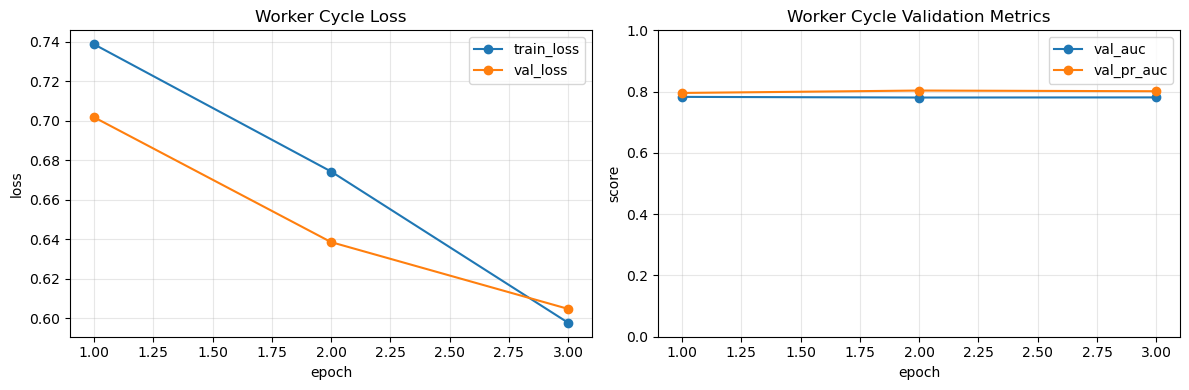

In [6]:
# Plot worker-cycle metrics across epochs.
if not history:
    raise RuntimeError("Worker history is empty. Run the worker round cell first.")

worker_epochs = [row["epoch"] for row in history]
worker_train_loss = [row["train_loss"] for row in history]
worker_val_loss = [row["val_loss"] for row in history]
worker_val_auc = [row["val_auc"] for row in history]
worker_val_pr_auc = [row["val_pr_auc"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(worker_epochs, worker_train_loss, marker="o", label="train_loss")
axes[0].plot(worker_epochs, worker_val_loss, marker="o", label="val_loss")
axes[0].set_title("Worker Cycle Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(worker_epochs, worker_val_auc, marker="o", label="val_auc")
axes[1].plot(worker_epochs, worker_val_pr_auc, marker="o", label="val_pr_auc")
axes[1].set_title("Worker Cycle Validation Metrics")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("score")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Manager / Control Plane

This section now uses a real local-LLM manager path.

The stack is:

- worker node: this `ResNet_trigger` directory
- control plane: `harness/claw-code/src/api_server.py`
- manager runtime: `claw`
- manager model: a local OpenAI-compatible model endpoint, for example Ollama

The local manager is expected to:

- inspect `/status`
- inspect `/memory`
- propose one bounded `train.py` experiment
- call `/run`
- inspect returned metrics
- call `/keep` or `/discard`
- summarize the cycle

By default this notebook runs the manager path in **fast-search screening mode**:

- reduced dataset size
- reduced trace length
- fewer epochs
- early stopping enabled
- test evaluation skipped during screening runs

What you need from your machine if you want to run it live:

- `uv` installed
- the node environment synced
- a built `claw` binary
- your local model backend running, for example Ollama at `http://localhost:11434`


In [7]:
# Manager runtime configuration.
MANAGER_MODE = "manual_codex"  # "manual_codex" or "claw"
RUN_MANAGER_CYCLE = True
TARGET_MANAGER_ROUNDS = 3
WORKER_RUNS_PER_MANAGER = 5
TOTAL_TARGET_WORKER_RUNS = TARGET_MANAGER_ROUNDS * WORKER_RUNS_PER_MANAGER

WORKER_BACKEND = "ollama"
WORKER_MODEL = "qwen2.5-coder:7b"
WORKER_HOST = "http://localhost:11434"

MANAGER_MODEL = "qwen2.5-coder:7b"
MANAGER_OPENAI_BASE_URL = "http://localhost:11434/v1"
API_HOST = "127.0.0.1"
PREFERRED_API_PORT = 7331
MANAGER_TIMEOUT_SECONDS = 3600
API_STARTUP_TIMEOUT_SECONDS = 20
MANAGER_PERMISSION_MODE = "workspace-write"
MANAGER_SKIP_PERMISSIONS = True
KEEP_MANUAL_API_SERVER_RUNNING = True

MANAGER_FAST_SEARCH = True
MANAGER_ENV = dict(FAST_SEARCH_ENV) if MANAGER_FAST_SEARCH else {}

MANAGER_RECORD_PATH = ARTIFACT_DIR / "manager_round_records.json"
MANAGER_PREVIEW_PATH = ARTIFACT_DIR / "manual_codex_manager_request.txt"
MANAGER_LOG_DIR = ARTIFACT_DIR / "manager_logs"
RUN_ARCHIVE_DIR = ARTIFACT_DIR / "run_archive"
MANAGER_LOG_DIR.mkdir(parents=True, exist_ok=True)
RUN_ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

MANAGER_PROMPT_TEMPLATE = """
You are the manager for an autoresearch worker node.

Operate through the local control-plane API at {api_base}.
Use shell tools such as curl to call the API endpoints. Do not edit source files directly.

Goal:
- complete manager round {round_index} of {target_rounds}
- finish exactly {runs_this_round} worker experiments in this round
- worker slots in this round: {worker_slot_start} to {worker_slot_end}
- inspect status and memory before the first run, then reuse memory after each worker run
- run bounded train.py-only experiments
- decide keep or discard after every worker run
- stop after this manager round is complete

Required workflow:
1. GET /status
2. GET /memory?limit=10
3. GET /memory-summary
4. For each worker slot from {worker_slot_start} to {worker_slot_end}:
   - propose exactly one bounded experiment that edits train.py only
   - POST /run with a JSON packet
   - inspect the JSON result
   - if recommended_status is keep, POST /keep with rationale; otherwise POST /discard with rationale
   - GET /memory-summary before proposing the next worker run
5. After the last worker run, GET /memory?limit=5
6. Return a concise JSON summary for the whole manager round

Packet constraints:
- worker may edit train.py only
- prefer one scalar change like LEARNING_RATE, WEIGHT_DECAY, DROPOUT, BATCH_SIZE, or one small architecture knob
- use train_command exactly: uv run train.py > run.log 2>&1
- use syntax_check_command exactly: python3 -m py_compile train.py
- keep timeout_seconds at {timeout_seconds}

This notebook runs the worker in fast-search screening mode unless told otherwise.

Return your final answer as JSON with keys:
api_base, round_index, worker_slots_completed, decisions, best_metric_seen, rationale, notes
""".strip()

def build_api_server_command(port: int) -> list[str]:
    return [
        sys.executable,
        "-m",
        "src.main",
        "api-server",
        "--root", str(NODE_ROOT),
        "--port", str(port),
        "--listen", API_HOST,
        "--backend", WORKER_BACKEND,
        "--model", WORKER_MODEL,
        "--host", WORKER_HOST,
    ]

def build_manager_prompt(api_base: str, round_index: int, worker_slot_start: int, runs_this_round: int) -> str:
    worker_slot_end = worker_slot_start + runs_this_round - 1
    return MANAGER_PROMPT_TEMPLATE.format(
        api_base=api_base,
        timeout_seconds=MANAGER_TIMEOUT_SECONDS,
        round_index=round_index,
        target_rounds=TARGET_MANAGER_ROUNDS,
        worker_slot_start=worker_slot_start,
        worker_slot_end=worker_slot_end,
        runs_this_round=runs_this_round,
    )

def build_claw_manager_command(prompt: str) -> list[str]:
    command = [
        str(CLAW_BINARY),
        "--output-format", "json",
    ]
    if MANAGER_SKIP_PERMISSIONS:
        command.append("--dangerously-skip-permissions")
    else:
        command.extend(["--permission-mode", MANAGER_PERMISSION_MODE])
    command.extend([
        "--model", MANAGER_MODEL,
        "prompt",
        prompt,
    ])
    return command

print("manager_mode:", MANAGER_MODE)
print("target_manager_rounds:", TARGET_MANAGER_ROUNDS)
print("worker_runs_per_manager:", WORKER_RUNS_PER_MANAGER)
print("total_target_worker_runs:", TOTAL_TARGET_WORKER_RUNS)
print("manager_timeout_seconds:", MANAGER_TIMEOUT_SECONDS)
print("manager_fast_search:", MANAGER_FAST_SEARCH)
print("manager_skip_permissions:", MANAGER_SKIP_PERMISSIONS)
print("manual_api_server_kept_running:", KEEP_MANUAL_API_SERVER_RUNNING)
print(json.dumps(MANAGER_ENV, indent=2))
print("manager_record_path:", MANAGER_RECORD_PATH)
print("manager_preview_path:", MANAGER_PREVIEW_PATH)
print("run_manager_cycle:", RUN_MANAGER_CYCLE)


manager_mode: manual_codex
target_manager_rounds: 3
worker_runs_per_manager: 5
total_target_worker_runs: 15
manager_timeout_seconds: 3600
manager_fast_search: True
manager_skip_permissions: True
manual_api_server_kept_running: True
{
  "RESNET_TRIGGER_FAST_SEARCH": "1",
  "RESNET_TRIGGER_FAST_N_SIGNAL": "1000",
  "RESNET_TRIGGER_FAST_N_NOISE": "1000",
  "RESNET_TRIGGER_FAST_TRACE_LEN": "4096",
  "RESNET_TRIGGER_FAST_BATCH_SIZE": "64",
  "RESNET_TRIGGER_FAST_EPOCHS": "3",
  "RESNET_TRIGGER_FAST_SKIP_TEST": "1",
  "RESNET_TRIGGER_EARLY_STOP_PATIENCE": "2",
  "RESNET_TRIGGER_EARLY_STOP_MIN_DELTA": "0.002"
}
manager_record_path: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manager_round_records.json
manager_preview_path: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manual_codex_manager_request.txt
run_manager_cycle: True


In [8]:
# Start the control plane, then run either automated claw rounds or manual Codex-manager mode.
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

api_server_runtime = globals().get("api_server_runtime")
manager_session_summary = None


def load_manager_round_records() -> list[dict]:
    if MANAGER_RECORD_PATH.exists():
        try:
            payload = json.loads(MANAGER_RECORD_PATH.read_text(encoding="utf-8"))
            if isinstance(payload, list):
                return payload
        except json.JSONDecodeError:
            pass
    return []


def save_manager_round_records(records: list[dict]) -> None:
    MANAGER_RECORD_PATH.write_text(json.dumps(records, indent=2), encoding="utf-8")


manager_round_records = load_manager_round_records()


def upsert_round_record(record: dict) -> None:
    key = (record.get("record_type"), record.get("round_index"))
    for idx, existing in enumerate(manager_round_records):
        if (existing.get("record_type"), existing.get("round_index")) == key:
            manager_round_records[idx] = record
            break
    else:
        manager_round_records.append(record)
    save_manager_round_records(manager_round_records)


def read_tail(path: Path, max_lines: int = 40) -> str:
    if not path.exists():
        return ""
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    return "\n".join(lines[-max_lines:])


def choose_api_port(host: str, preferred_port: int) -> int:
    def can_bind(port: int) -> bool:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
            sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            try:
                sock.bind((host, port))
            except OSError:
                return False
            return True

    if can_bind(preferred_port):
        return preferred_port
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.bind((host, 0))
        return int(sock.getsockname()[1])


def http_get_json(url: str, timeout: int = 30) -> dict:
    with urlopen(url, timeout=timeout) as response:
        return json.loads(response.read().decode("utf-8"))


def http_post_json(url: str, payload: dict, timeout: int = 300) -> tuple[int, dict]:
    request = Request(
        url,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    try:
        with urlopen(request, timeout=timeout) as response:
            body = response.read().decode("utf-8")
            return response.status, json.loads(body) if body else {}
    except HTTPError as error:
        body = error.read().decode("utf-8")
        parsed = json.loads(body) if body else {"error": body}
        return error.code, parsed


def load_results_rows() -> list[dict]:
    results_path = NODE_ROOT / "results.tsv"
    if not results_path.exists():
        return []
    lines = [line for line in results_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if len(lines) < 2:
        return []
    header = lines[0].split("\t")
    return [dict(zip(header, line.split("\t"))) for line in lines[1:]]


def current_progress(rows: list[dict]) -> dict:
    completed_runs = len(rows)
    manager_round = (completed_runs // WORKER_RUNS_PER_MANAGER) + 1
    worker_slot = (completed_runs % WORKER_RUNS_PER_MANAGER) + 1
    runs_remaining_this_round = WORKER_RUNS_PER_MANAGER - ((worker_slot - 1) % WORKER_RUNS_PER_MANAGER)
    done = completed_runs >= TOTAL_TARGET_WORKER_RUNS
    if done:
        manager_round = TARGET_MANAGER_ROUNDS
        worker_slot = WORKER_RUNS_PER_MANAGER
        runs_remaining_this_round = 0
    return {
        "completed_runs": completed_runs,
        "manager_round": manager_round,
        "worker_slot": worker_slot,
        "runs_remaining_this_round": runs_remaining_this_round,
        "done": done,
    }


def capture_manager_snapshot(api_base: str) -> dict:
    rows = load_results_rows()
    snapshot = {
        "status": http_get_json(f"{api_base}/status"),
        "memory": http_get_json(f"{api_base}/memory?limit=10"),
        "memory_summary": http_get_json(f"{api_base}/memory-summary"),
        "results_rows": len(rows),
        "progress": current_progress(rows),
    }
    return snapshot


def sync_completed_manual_rounds(api_base: str) -> None:
    rows = load_results_rows()
    completed_runs = len(rows)
    for round_index in range(1, TARGET_MANAGER_ROUNDS + 1):
        completed_for_round = min(max(completed_runs - ((round_index - 1) * WORKER_RUNS_PER_MANAGER), 0), WORKER_RUNS_PER_MANAGER)
        if completed_for_round < WORKER_RUNS_PER_MANAGER:
            continue
        record = {
            "record_type": "manual_codex_completed",
            "round_index": round_index,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "api_base": api_base,
            "completed_worker_runs": completed_for_round,
            "cumulative_completed_runs": completed_runs,
            "memory_summary_after": http_get_json(f"{api_base}/memory-summary"),
        }
        upsert_round_record(record)


def wait_for_health(api_base: str, timeout_seconds: float = API_STARTUP_TIMEOUT_SECONDS) -> None:
    deadline = time.time() + timeout_seconds
    last_error = None
    while time.time() < deadline:
        try:
            payload = http_get_json(f"{api_base}/health", timeout=2)
            if payload.get("status") == "ok":
                return
        except Exception as error:
            last_error = error
            time.sleep(0.25)
    raise RuntimeError(f"API server did not become healthy: {last_error}")


def start_api_server() -> dict:
    global api_server_runtime
    if api_server_runtime is not None:
        proc = api_server_runtime["proc"]
        if proc.poll() is None:
            return api_server_runtime
        log_handle = api_server_runtime.get("log_handle")
        if log_handle is not None and not log_handle.closed:
            log_handle.close()
        api_server_runtime = None

    port = choose_api_port(API_HOST, PREFERRED_API_PORT)
    api_base = f"http://{API_HOST}:{port}"
    api_env = os.environ.copy()
    api_env["PYTHONPATH"] = str(CLAW_ROOT)
    api_env["RESNET_TRIGGER_DEVICE"] = str(WORKER_DEVICE)
    api_env.update(MANAGER_ENV)

    log_path = MANAGER_LOG_DIR / f"api_server_{port}.log"
    log_handle = log_path.open("a", encoding="utf-8")
    proc = subprocess.Popen(
        build_api_server_command(port),
        cwd=CLAW_ROOT,
        env=api_env,
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        text=True,
    )
    wait_for_health(api_base, timeout_seconds=API_STARTUP_TIMEOUT_SECONDS)
    api_server_runtime = {
        "proc": proc,
        "api_base": api_base,
        "port": port,
        "log_path": log_path,
        "log_handle": log_handle,
        "started_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    return api_server_runtime


def stop_api_server() -> None:
    global api_server_runtime
    if api_server_runtime is None:
        return
    proc = api_server_runtime["proc"]
    if proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
            proc.wait(timeout=5)
    log_handle = api_server_runtime.get("log_handle")
    if log_handle is not None and not log_handle.closed:
        log_handle.close()
    api_server_runtime = None


def stream_subprocess(command: list[str], *, cwd: Path, env: dict, timeout_seconds: int, log_path: Path, prefix: str = "") -> tuple[int, str]:
    proc = subprocess.Popen(
        command,
        cwd=cwd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    line_queue: queue.Queue[str | None] = queue.Queue()

    def reader() -> None:
        try:
            assert proc.stdout is not None
            for line in proc.stdout:
                line_queue.put(line)
        finally:
            line_queue.put(None)

    threading.Thread(target=reader, daemon=True).start()
    output_lines: list[str] = []
    deadline = time.time() + timeout_seconds
    saw_eof = False

    with log_path.open("w", encoding="utf-8") as log_file:
        while True:
            if time.time() > deadline:
                proc.kill()
                try:
                    proc.wait(timeout=5)
                except subprocess.TimeoutExpired:
                    pass
                raise TimeoutError(f"Process timed out after {timeout_seconds} seconds: {shlex.join(command)}")

            try:
                item = line_queue.get(timeout=0.5)
            except queue.Empty:
                if proc.poll() is not None and saw_eof:
                    break
                continue

            if item is None:
                saw_eof = True
                if proc.poll() is not None:
                    break
                continue

            print(f"{prefix}{item}", end="")
            log_file.write(item)
            log_file.flush()
            output_lines.append(item)

    return proc.wait(), "".join(output_lines)


def parse_json_events(output_text: str) -> list[dict]:
    events: list[dict] = []
    for line in output_text.splitlines():
        stripped = line.strip()
        if not stripped:
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, dict):
            events.append(parsed)
    return events


def build_manual_codex_request(api_base: str, round_index: int, worker_slot_start: int, runs_this_round: int, snapshot: dict) -> str:
    worker_slot_end = worker_slot_start + runs_this_round - 1
    instructions = f"""
Manual Codex manager round {round_index}/{TARGET_MANAGER_ROUNDS}

API base: {api_base}
Record path: {MANAGER_RECORD_PATH}
Worker slots for this manager round: {worker_slot_start} to {worker_slot_end}
This means {runs_this_round} worker runs in this manager round.

Use this Codex session as the manager. In this session, drive exactly this manager round:
1. GET {api_base}/status
2. GET {api_base}/memory?limit=10
3. GET {api_base}/memory-summary
4. For each worker slot {worker_slot_start}..{worker_slot_end}:
   - propose one train.py-only experiment
   - POST {api_base}/run with a JSON packet
   - read the result
   - POST {api_base}/keep or POST {api_base}/discard with rationale
   - GET {api_base}/memory-summary before proposing the next worker run
5. After worker slot {worker_slot_end}, GET {api_base}/memory?limit=5 and summarize the round.

Current snapshot:
{json.dumps(snapshot, indent=2)}
""".strip()
    return instructions


runtime = start_api_server()
api_base = runtime["api_base"]
rows_before = load_results_rows()
progress = current_progress(rows_before)
sync_completed_manual_rounds(api_base)
manager_session_summary = {
    "manager_mode": MANAGER_MODE,
    "api_base": api_base,
    "target_manager_rounds": TARGET_MANAGER_ROUNDS,
    "worker_runs_per_manager": WORKER_RUNS_PER_MANAGER,
    "total_target_worker_runs": TOTAL_TARGET_WORKER_RUNS,
    "completed_worker_cycles": progress["completed_runs"],
    "next_manager_round": progress["manager_round"],
    "next_worker_slot": progress["worker_slot"],
    "manager_record_path": str(MANAGER_RECORD_PATH),
    "api_server_log_path": str(runtime["log_path"]),
}

print(json.dumps(manager_session_summary, indent=2))
print("api_server_tail:\n" + (read_tail(runtime["log_path"], max_lines=10) or "<no api log output yet>"))

if RUN_MANAGER_CYCLE:
    if progress["done"]:
        print(f"All {TOTAL_TARGET_WORKER_RUNS} worker runs are already complete.")
        if MANAGER_MODE != "manual_codex" or not KEEP_MANUAL_API_SERVER_RUNNING:
            stop_api_server()
    elif MANAGER_MODE == "claw":
        claw_env = os.environ.copy()
        claw_env["OPENAI_BASE_URL"] = MANAGER_OPENAI_BASE_URL
        claw_env["OPENAI_API_KEY"] = claw_env.get("OPENAI_API_KEY", "local") or "local"
        claw_env["ANTHROPIC_API_KEY"] = ""
        claw_env["ANTHROPIC_AUTH_TOKEN"] = ""

        round_records = []
        try:
            current_round = progress["manager_round"]
            current_slot = progress["worker_slot"]
            for round_index in range(current_round, TARGET_MANAGER_ROUNDS + 1):
                runs_this_round = WORKER_RUNS_PER_MANAGER if round_index != current_round else progress["runs_remaining_this_round"]
                slot_start = current_slot if round_index == current_round else 1
                print(f"\n=== claw manager round {round_index}/{TARGET_MANAGER_ROUNDS} slots {slot_start}-{slot_start + runs_this_round - 1} ===")
                prompt = build_manager_prompt(api_base, round_index, slot_start, runs_this_round)
                claw_manager_command = build_claw_manager_command(prompt)
                log_path = MANAGER_LOG_DIR / f"claw_round_{round_index}.log"
                print("command:", shlex.join(claw_manager_command))
                returncode, output_text = stream_subprocess(
                    claw_manager_command,
                    cwd=NODE_ROOT,
                    env=claw_env,
                    timeout_seconds=MANAGER_TIMEOUT_SECONDS,
                    log_path=log_path,
                    prefix="[claw] ",
                )
                if returncode != 0:
                    raise RuntimeError(
                        f"claw manager round {round_index} failed with return code {returncode}. Log: {log_path}"
                    )
                snapshot_after = capture_manager_snapshot(api_base)
                events = parse_json_events(output_text)
                record = {
                    "record_type": "claw_completed",
                    "round_index": round_index,
                    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                    "api_base": api_base,
                    "worker_slot_start": slot_start,
                    "worker_slot_end": slot_start + runs_this_round - 1,
                    "completed_worker_runs_this_round": runs_this_round,
                    "returncode": returncode,
                    "log_path": str(log_path),
                    "output_event_count": len(events),
                    "last_event": events[-1] if events else None,
                    "results_rows": len(load_results_rows()),
                    "status_after": snapshot_after["status"],
                    "memory_summary_after": snapshot_after["memory_summary"],
                }
                upsert_round_record(record)
                round_records.append(record)
                print(json.dumps(record, indent=2))
                current_slot = 1
        finally:
            stop_api_server()

        manager_session_summary = {
            "manager_mode": "claw",
            "rounds_completed_this_run": len(round_records),
            "target_manager_rounds": TARGET_MANAGER_ROUNDS,
            "worker_runs_per_manager": WORKER_RUNS_PER_MANAGER,
            "manager_record_path": str(MANAGER_RECORD_PATH),
        }
        print("\nmanager_session_summary:")
        print(json.dumps(manager_session_summary, indent=2))
    elif MANAGER_MODE == "manual_codex":
        snapshot = capture_manager_snapshot(api_base)
        round_index = progress["manager_round"]
        worker_slot_start = progress["worker_slot"]
        runs_this_round = progress["runs_remaining_this_round"]
        manual_request = build_manual_codex_request(api_base, round_index, worker_slot_start, runs_this_round, snapshot)
        MANAGER_PREVIEW_PATH.write_text(manual_request, encoding="utf-8")
        record = {
            "record_type": "manual_codex_ready",
            "round_index": round_index,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "api_base": api_base,
            "worker_slot_start": worker_slot_start,
            "worker_slot_end": worker_slot_start + runs_this_round - 1,
            "planned_worker_runs": runs_this_round,
            "preview_path": str(MANAGER_PREVIEW_PATH),
            "api_server_log_path": str(runtime["log_path"]),
            "status_snapshot": snapshot["status"],
            "memory_summary_snapshot": snapshot["memory_summary"],
            "results_rows": snapshot["results_rows"],
        }
        upsert_round_record(record)
        print("\nManual Codex manager request saved to:", MANAGER_PREVIEW_PATH)
        print("\n" + manual_request)
        if not KEEP_MANUAL_API_SERVER_RUNNING:
            stop_api_server()
    else:
        raise ValueError(f"Unsupported manager mode: {MANAGER_MODE}")
else:
    print("Manager cycle not executed. Set RUN_MANAGER_CYCLE = True to run the manager section.")


{
  "manager_mode": "manual_codex",
  "api_base": "http://127.0.0.1:7331",
  "target_manager_rounds": 3,
  "worker_runs_per_manager": 5,
  "total_target_worker_runs": 15,
  "completed_worker_cycles": 0,
  "next_manager_round": 1,
  "next_worker_slot": 1,
  "manager_record_path": "/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manager_round_records.json",
  "api_server_log_path": "/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manager_logs/api_server_7331.log"
}
api_server_tail:
[api] backend=OllamaBackend(model='qwen2.5-coder:7b', host='http://localhost:11434')
[api] Press Ctrl-C to stop.
[api] 127.0.0.1 "GET /health HTTP/1.1" 200 -
[api] 127.0.0.1 "GET /status HTTP/1.1" 200 -
[api] 127.0.0.1 "GET /memory?limit=10 HTTP/1.1" 200 -
[api] 127.0.0.1 "GET /memory-summary HTTP/1.1" 200 -
[api] autoresearch API listening on http://127.0.0.1:7331  root=/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger
[api

### Manager Block Plotting

The manager section now targets a real `3 x 5` structure:

- `TARGET_MANAGER_ROUNDS = 3`
- `WORKER_RUNS_PER_MANAGER = 5`
- total worker runs = `15`

Manager mode options:

- `MANAGER_MODE = "claw"`: run one full manager block through `claw`, stream output live, and stop after five worker runs for that block.
- `MANAGER_MODE = "manual_codex"`: keep the control-plane API server running, print a briefing for this Codex session, and let Codex complete the five worker runs for the current manager block.

The plots below cover three views:

- overall performance across all `15` worker runs
- per-manager-block performance across the `3` outer rounds
- archived epoch traces for each worker run, which gives the `3 x 5 x 3` style view once enough runs have been completed


In [9]:
# Plot manager-block and archived worker-run metrics.
results_path = NODE_ROOT / "results.tsv"
manager_record_rows = []
if MANAGER_RECORD_PATH.exists():
    try:
        manager_record_rows = json.loads(MANAGER_RECORD_PATH.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        manager_record_rows = []

if not results_path.exists():
    raise RuntimeError(f"Missing results file: {results_path}")

lines = [line for line in results_path.read_text(encoding="utf-8").splitlines() if line.strip()]
if len(lines) < 2:
    raise RuntimeError("results.tsv does not contain any completed experiments yet.")

header = lines[0].split("	")
rows = [dict(zip(header, line.split("	"))) for line in lines[1:]]
if not rows:
    raise RuntimeError("No data rows found in results.tsv")

metric_key = None
for candidate in ("val_bpb", "best_val_auc", "metric"):
    if candidate in header:
        metric_key = candidate
        break
if metric_key is None:
    raise RuntimeError(f"Could not find a known metric column in results.tsv header: {header}")

worker_run_index = list(range(1, len(rows) + 1))
manager_round_index = [((idx - 1) // WORKER_RUNS_PER_MANAGER) + 1 for idx in worker_run_index]
worker_slot_index = [((idx - 1) % WORKER_RUNS_PER_MANAGER) + 1 for idx in worker_run_index]
manager_decisions = [row.get("decision", "") for row in rows]

if metric_key == "val_bpb":
    worker_metric = [1.0 - float(row[metric_key]) for row in rows]
    metric_label = "candidate_val_auc_from_val_bpb"
else:
    worker_metric = [float(row[metric_key]) for row in rows]
    metric_label = metric_key

running_best = []
current_best = None
for value in worker_metric:
    current_best = value if current_best is None else max(current_best, value)
    running_best.append(current_best)

round_best = []
round_mean = []
heatmap = np.full((TARGET_MANAGER_ROUNDS, WORKER_RUNS_PER_MANAGER), np.nan)
for round_index in range(1, TARGET_MANAGER_ROUNDS + 1):
    values = [metric for metric, manager_round in zip(worker_metric, manager_round_index) if manager_round == round_index]
    if values:
        round_best.append(max(values))
        round_mean.append(float(np.mean(values)))
    else:
        round_best.append(np.nan)
        round_mean.append(np.nan)
for metric, manager_round, worker_slot in zip(worker_metric, manager_round_index, worker_slot_index):
    if manager_round <= TARGET_MANAGER_ROUNDS and worker_slot <= WORKER_RUNS_PER_MANAGER:
        heatmap[manager_round - 1, worker_slot - 1] = metric

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_global, ax_block, ax_heatmap, ax_epoch = axes.flatten()

for round_index in range(1, TARGET_MANAGER_ROUNDS + 1):
    xs = [x for x, r in zip(worker_run_index, manager_round_index) if r == round_index]
    ys = [y for y, r in zip(worker_metric, manager_round_index) if r == round_index]
    if xs:
        ax_global.plot(xs, ys, marker="o", label=f"manager_round_{round_index}")
ax_global.plot(worker_run_index, running_best, linestyle="--", color="black", label="running_best_auc")
keep_x = [x for x, d in zip(worker_run_index, manager_decisions) if d == "keep"]
keep_y = [y for y, d in zip(worker_metric, manager_decisions) if d == "keep"]
discard_x = [x for x, d in zip(worker_run_index, manager_decisions) if d and d != "keep"]
discard_y = [y for y, d in zip(worker_metric, manager_decisions) if d and d != "keep"]
if keep_x:
    ax_global.scatter(keep_x, keep_y, color="green", s=70, label="keep")
if discard_x:
    ax_global.scatter(discard_x, discard_y, color="red", s=70, label="discard")
ax_global.set_title("All Worker Runs Across Manager Blocks")
ax_global.set_xlabel("global worker run index")
ax_global.set_ylabel(metric_label)
ax_global.grid(True, alpha=0.3)
ax_global.legend()

block_x = list(range(1, TARGET_MANAGER_ROUNDS + 1))
ax_block.plot(block_x, round_best, marker="o", label="round_best_auc")
ax_block.plot(block_x, round_mean, marker="o", label="round_mean_auc")
ax_block.set_title("Per-Manager-Round Summary")
ax_block.set_xlabel("manager round")
ax_block.set_ylabel("AUC-like score")
ax_block.set_xticks(block_x)
ax_block.grid(True, alpha=0.3)
ax_block.legend()

im = ax_heatmap.imshow(heatmap, aspect="auto", interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
ax_heatmap.set_title("Manager Round x Worker Slot Heatmap")
ax_heatmap.set_xlabel("worker slot inside manager round")
ax_heatmap.set_ylabel("manager round")
ax_heatmap.set_xticks(range(WORKER_RUNS_PER_MANAGER))
ax_heatmap.set_xticklabels(range(1, WORKER_RUNS_PER_MANAGER + 1))
ax_heatmap.set_yticks(range(TARGET_MANAGER_ROUNDS))
ax_heatmap.set_yticklabels(range(1, TARGET_MANAGER_ROUNDS + 1))
fig.colorbar(im, ax=ax_heatmap, fraction=0.046, pad=0.04)

archive_paths = sorted(RUN_ARCHIVE_DIR.glob("run_*.json"), key=lambda p: p.stat().st_mtime)
archive_paths = archive_paths[: len(rows)]
epoch_matrix = None
if archive_paths:
    max_epochs = 0
    archive_histories = []
    for path in archive_paths:
        payload = json.loads(path.read_text(encoding="utf-8"))
        history_rows = payload.get("history", [])
        archive_histories.append(history_rows)
        max_epochs = max(max_epochs, len(history_rows))
    epoch_matrix = np.full((len(archive_histories), max_epochs), np.nan)
    for run_idx, history_rows in enumerate(archive_histories):
        for epoch_idx, row in enumerate(history_rows):
            epoch_matrix[run_idx, epoch_idx] = float(row.get("val_auc", np.nan))
    epoch_im = ax_epoch.imshow(epoch_matrix, aspect="auto", interpolation="nearest", cmap="magma", vmin=0.0, vmax=1.0)
    ax_epoch.set_title("Archived Epoch Val AUC (Run x Epoch)")
    ax_epoch.set_xlabel("epoch")
    ax_epoch.set_ylabel("worker run")
    ax_epoch.set_xticks(range(max_epochs))
    ax_epoch.set_xticklabels(range(1, max_epochs + 1))
    ax_epoch.set_yticks(range(len(archive_histories)))
    ax_epoch.set_yticklabels([f"M{manager_round_index[i]}-W{worker_slot_index[i]}" for i in range(len(archive_histories))])
    fig.colorbar(epoch_im, ax=ax_epoch, fraction=0.046, pad=0.04)
else:
    ax_epoch.set_title("Archived Epoch Val AUC (Run x Epoch)")
    ax_epoch.text(0.5, 0.5, "No archived run histories yet", ha="center", va="center")
    ax_epoch.set_axis_off()

plt.tight_layout()
plt.show()

print("metric_key:", metric_key)
print("worker_runs_completed:", len(rows))
print("manager_rounds_target:", TARGET_MANAGER_ROUNDS)
print("worker_runs_per_manager:", WORKER_RUNS_PER_MANAGER)
print("latest_decision:", manager_decisions[-1] if manager_decisions else None)
print("manager_record_path:", MANAGER_RECORD_PATH)
print("manager_record_count:", len(manager_record_rows))
print("archive_run_count:", len(archive_paths))
if manager_record_rows:
    print("latest_manager_record_type:", manager_record_rows[-1].get("record_type"))
    print("latest_manager_round:", manager_record_rows[-1].get("round_index"))


RuntimeError: results.tsv does not contain any completed experiments yet.

### Manager Command Preview

This final cell previews the next manager block.

- for `claw`, it prints the exact command shape for the next full manager round
- for `manual_codex`, it prints the saved request for the next five-worker manager block in this Codex session

Use this as the handoff surface between the notebook, the control plane, and the manager.


In [ ]:
from pathlib import Path
import shlex

node_root_local = globals().get("NODE_ROOT", Path.cwd())
artifact_dir_local = globals().get("ARTIFACT_DIR", node_root_local / "artifacts")
manager_mode = globals().get("MANAGER_MODE", "manual_codex")
target_manager_rounds = globals().get("TARGET_MANAGER_ROUNDS", 3)
worker_runs_per_manager = globals().get("WORKER_RUNS_PER_MANAGER", 5)
total_target_worker_runs = globals().get("TOTAL_TARGET_WORKER_RUNS", target_manager_rounds * worker_runs_per_manager)

def _fallback_load_results_rows() -> list[dict]:
    results_path_local = node_root_local / "results.tsv"
    if not results_path_local.exists():
        return []
    lines_local = [line for line in results_path_local.read_text(encoding="utf-8").splitlines() if line.strip()]
    if len(lines_local) < 2:
        return []
    header_local = lines_local[0].split("\t")
    return [dict(zip(header_local, line.split("\t"))) for line in lines_local[1:]]

def _fallback_current_progress(rows_local: list[dict]) -> dict:
    completed_runs = len(rows_local)
    manager_round_local = (completed_runs // worker_runs_per_manager) + 1
    worker_slot_local = (completed_runs % worker_runs_per_manager) + 1
    runs_remaining_local = worker_runs_per_manager - ((worker_slot_local - 1) % worker_runs_per_manager)
    done_local = completed_runs >= total_target_worker_runs
    if done_local:
        manager_round_local = target_manager_rounds
        worker_slot_local = worker_runs_per_manager
        runs_remaining_local = 0
    return {
        "completed_runs": completed_runs,
        "manager_round": manager_round_local,
        "worker_slot": worker_slot_local,
        "runs_remaining_this_round": runs_remaining_local,
        "done": done_local,
    }

results_rows_now = load_results_rows() if "load_results_rows" in globals() else _fallback_load_results_rows()
progress_now = current_progress(results_rows_now) if "current_progress" in globals() else _fallback_current_progress(results_rows_now)
print("manager_mode:", manager_mode)
print("completed_worker_runs:", progress_now["completed_runs"])
print("next_manager_round:", progress_now["manager_round"])
print("next_worker_slot:", progress_now["worker_slot"])

if manager_mode == "claw":
    api_server_runtime_local = globals().get("api_server_runtime")
    api_host = globals().get("API_HOST", "127.0.0.1")
    preferred_api_port = globals().get("PREFERRED_API_PORT", 7331)
    preview_api_base = api_server_runtime_local["api_base"] if api_server_runtime_local is not None else f"http://{api_host}:{preferred_api_port}"
    if progress_now["done"]:
        print("All manager rounds are already complete.")
    elif "build_manager_prompt" not in globals() or "build_claw_manager_command" not in globals():
        print("Manager helpers are not loaded. Run the manager configuration cell and the manager control-plane cell first.")
        print("preview_api_base:", preview_api_base)
    else:
        preview_prompt = build_manager_prompt(
            preview_api_base,
            progress_now["manager_round"],
            progress_now["worker_slot"],
            progress_now["runs_remaining_this_round"],
        )
        preview_command = build_claw_manager_command(preview_prompt)
        print("Raw claw manager command preview:")
        print(shlex.join(preview_command))
        print("manager_openai_base_url:", globals().get("MANAGER_OPENAI_BASE_URL", "http://localhost:11434/v1"))
        claw_binary = globals().get("CLAW_BINARY")
        print("claw_binary_exists:", claw_binary.exists() if claw_binary is not None else False)
else:
    preview_path = globals().get("MANAGER_PREVIEW_PATH", artifact_dir_local / "manual_codex_manager_request.txt")
    print("manual_codex_preview_path:", preview_path)
    if preview_path.exists():
        print(preview_path.read_text(encoding="utf-8"))
    else:
        print("No manual Codex preview has been written yet. Run the manager control-plane cell first.")


manager_mode: manual_codex
manual_codex_preview_path: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manual_codex_manager_request.txt
Manual Codex manager round 1/3

API base: http://127.0.0.1:7331
Record path: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/manager_round_records.json
Worker slots for this manager round: 1 to 5
This means 5 worker runs in this manager round.

Use this Codex session as the manager. In this session, drive exactly this manager round:
1. GET http://127.0.0.1:7331/status
2. GET http://127.0.0.1:7331/memory?limit=10
3. GET http://127.0.0.1:7331/memory-summary
4. For each worker slot 1..5:
   - propose one train.py-only experiment
   - POST http://127.0.0.1:7331/run with a JSON packet
   - read the result
   - POST http://127.0.0.1:7331/keep or POST http://127.0.0.1:7331/discard with rationale
   - GET http://127.0.0.1:7331/memory-summary before proposing the next worker run
5. After worker sl